In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Load data

In [59]:
input_csv_file = "results.csv"

df = pd.read_csv(
    input_csv_file,
    sep=';',
    header=0,
    skipinitialspace=True
)

df['time'] = pd.to_numeric(df['time'], errors='coerce')
df['array_size'] = pd.to_numeric(df['array_size'], errors='coerce', downcast='integer')
df['threads'] = pd.to_numeric(df['threads'], errors='coerce', downcast='integer')
df['chunk_size'] = pd.to_numeric(df['chunk_size'], errors='coerce', downcast='integer')
df['scheduler'] = df['scheduler'].str.strip()

df.head()

,array_size,threads,scheduler,chunk_size,time
0,2000000,1,static,1,0.022200
1,2000000,1,static,100,0.013356
2,2000000,1,static,10000,0.012962
3,2000000,1,static,200000,0.020603
4,2000000000,1,static,1,10.368890


# Aggregation

In [60]:
agg_df = df.groupby(['array_size', 'threads', 'scheduler', 'chunk_size'])['time'].agg(['mean', 'std']).reset_index()
agg_df.fillna({'std': 0}, inplace=True)

agg_df.head()

,array_size,threads,scheduler,chunk_size,mean,std
0,2000000,1,dynamic,1,0.034684,0.0
1,2000000,1,dynamic,100,0.012351,0.0
2,2000000,1,dynamic,10000,0.012026,0.0
3,2000000,1,dynamic,200000,0.017887,0.0
4,2000000,1,guided,1,0.013205,0.0


# Analysis & Visualization

### Plot 1 - Execution time

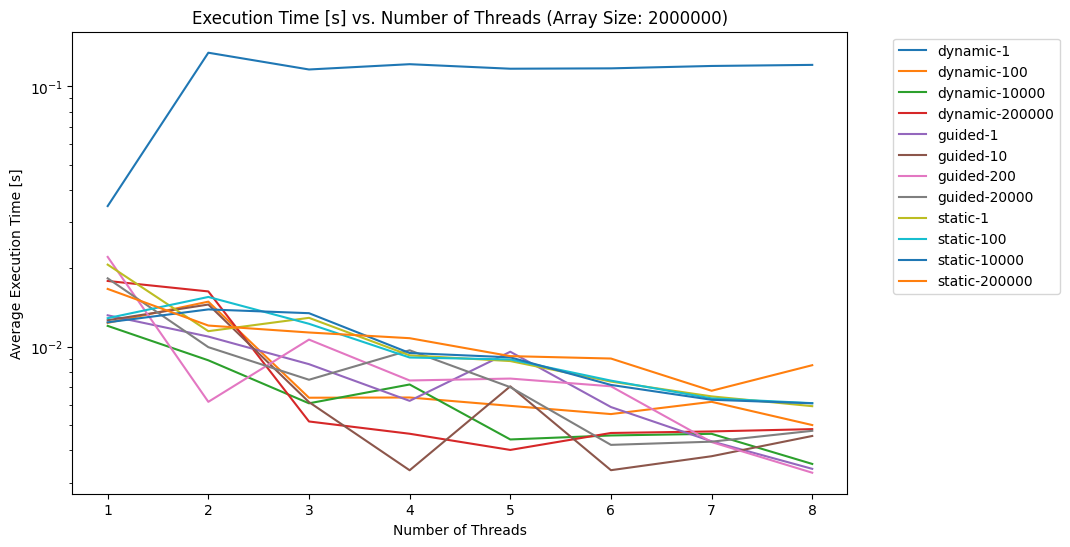

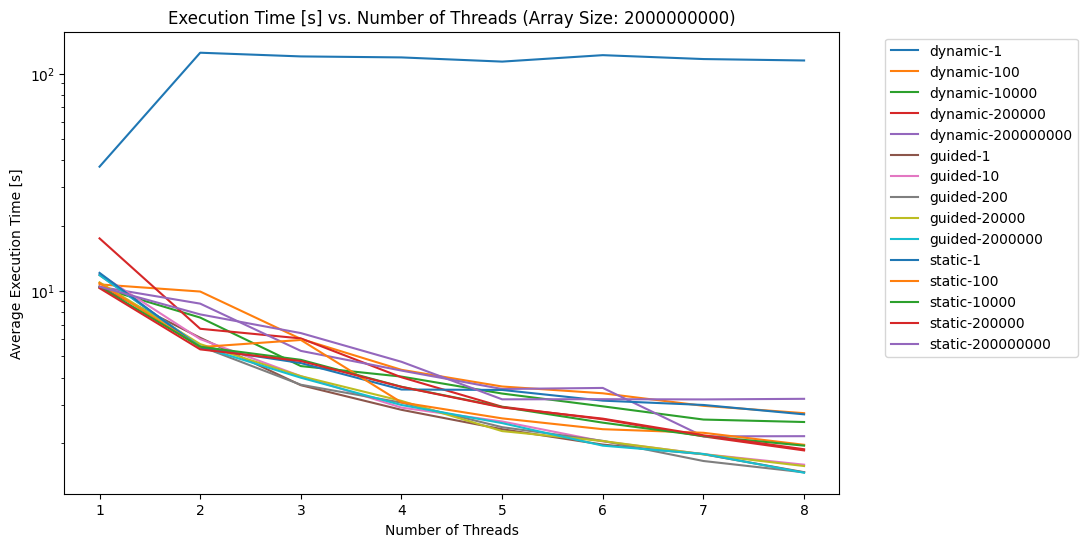

In [61]:
for asize in agg_df["array_size"].unique():
    plt.figure(figsize=(10, 6))
    df = agg_df[agg_df["array_size"] == asize]
    for series in df.groupby(["scheduler", "chunk_size"]):
        series_df = series[1]
        series_nm = series[0]
        plt.plot(series_df["threads"], series_df["mean"], label=f"{series_nm[0]}-{series_nm[1]}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title(f'Execution Time [s] vs. Number of Threads (Array Size: {asize})')
    plt.xlabel('Number of Threads')
    plt.ylabel('Average Execution Time [s]')
    plt.yscale("log")
    # plt.savefig(f"execution-time-{asize}")
    plt.show()